Series de Taylor con sympy

Cálculo de derivadas con sp.diff
Primera Derivada
2*sin(x) + 5*cos(x)
Quinta Derivada
2*sin(x) + 5*cos(x)


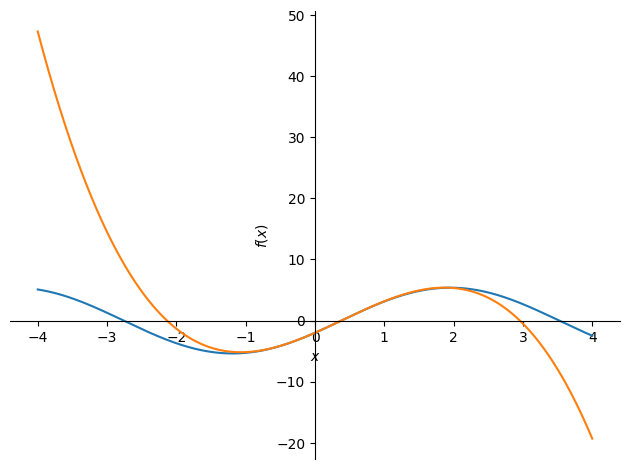

In [12]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

xsym = sp.symbols('x')

fejemplo = 5*sp.sin(xsym)-2*sp.cos(xsym) 
xo   = 0
grado = 3


print('Cálculo de derivadas con sp.diff')
print('Primera Derivada')
print(sp.diff(fejemplo,xsym,1))
print('Quinta Derivada')
print(sp.diff(fejemplo,xsym,5))

Polinomio = fejemplo.subs(xsym,xo)

#Ciclo for para los términos polinomiales

for k in range(1,grado+1):
    Derivada = sp.diff(fejemplo,xsym,k)
    Pendiente = Derivada.subs(xsym,xo)
    Polinomio += Pendiente*(xsym-xo)**k/sp.factorial(k)
    #print('Polinomio de grado',k)
    #print(Polinomio)

sp.plot(fejemplo,Polinomio,(xsym,-4,4))



Definicion de Series de Taylor:

In [41]:
def SeriesTaylor(funcion,xnumero,terminos,intervalo):

   Polinomio = funcion.subs(xsym,xnumero)

   #Evaluación simbólica de los términos del polinomio
   for k in range(1,terminos+1):
        Derivada = sp.diff(funcion,xsym,k)
        Pendiente = Derivada.subs(xsym,xnumero)
        Polinomio += Pendiente*(xsym-xnumero)**k/sp.factorial(k)

    #Grafica comparativa con numpy
   Polinomio = sp.lambdify(xsym,Polinomio)  #Evalue el polinomio de manera numerica
   funcion = sp.lambdify(xsym,funcion)
   xvals = np.linspace(intervalo[0],intervalo[1])
   yexact = funcion(xvals)
   yaprox = Polinomio(xvals)
   plt.plot(xvals,yexact,label='Exacto')
   plt.plot(xvals,yaprox,label=f'grado {terminos}')
   plt.title(f'Gráfica comparativa entre la función y el polinimio de grado {terminos}')
   plt.legend(loc='best')
   plt.ylim(min(yaprox),max(yaprox))
   plt.grid()
   plt.show()

   return xvals,yaprox,yexact
    
 

Ejemplos Ilustrativos




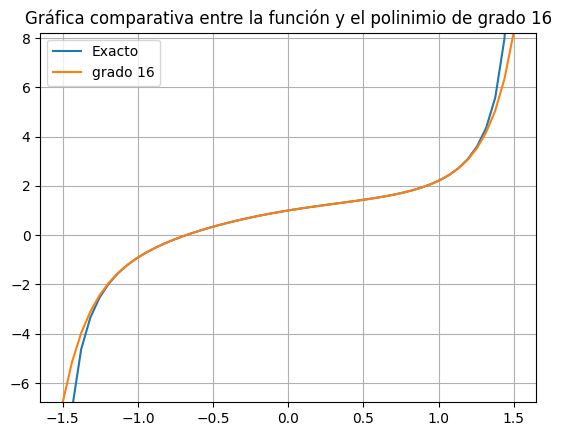

In [42]:
f2 = sp.sech(xsym) + sp.tan(xsym)
grado = 16
intervalo =[-1.5,1.5]

x2,y2aprox,y2exact= SeriesTaylor(f2,0,grado,intervalo)

Agregue un slider a la gráfica para cambiar el grado del polinomio

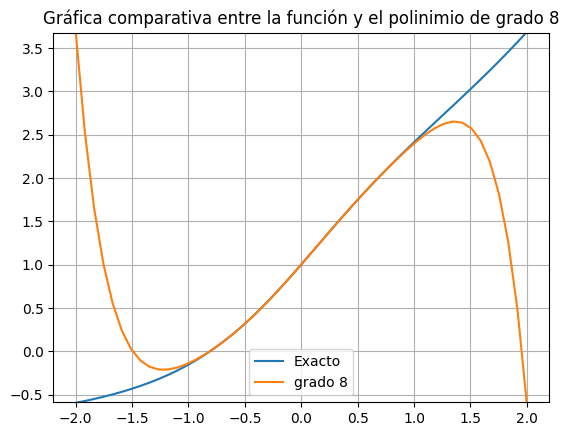

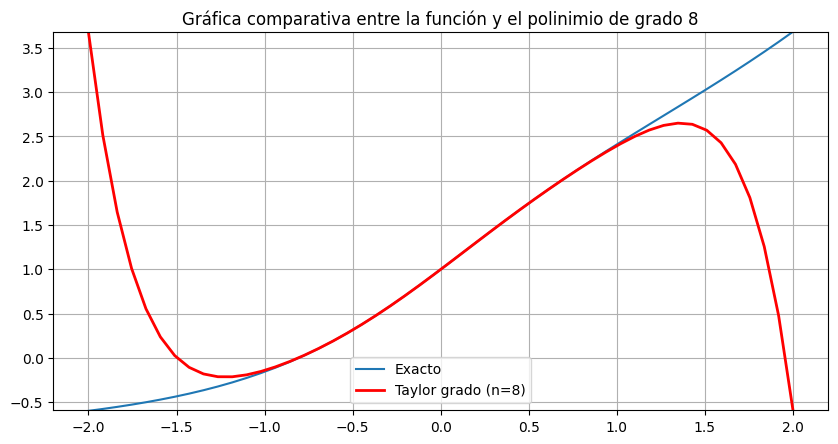

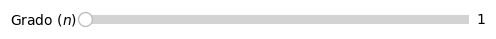

In [ ]:

funcion = sp.exp(0.5*xsym) + sp.tanh(xsym)
intervalo = [-2,2]
terminos = 8
xvals,yaprox,yexact= SeriesTaylor(funcion,0,terminos,intervalo)

fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)  # Ambiente del Slider
plt.plot(xvals,yexact,label='Exacto')
curva_aprox = ax.plot(xvals, yaprox, 'r-', label=f'Taylor grado (n={terminos})', linewidth=2)
#plt.plot(xvals,yaprox,label=f'grado {terminos}')
plt.title(f'Gráfica comparativa entre la función y el polinimio de grado {terminos}')
plt.legend(loc='best')
plt.ylim(min(yaprox),max(yaprox))
plt.grid()
plt.show()

#Agregue la regla
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.04])  # Dimensiones de la regla: [left, bottom, width, height]
slider_degree = Slider(
    ax=ax_slider,
    label='Grado ($n$)',
    valmin=1,
    valmax=32,
    valinit=1,
    valstep=1,  # Forces integer step increments
    color='crimson'
)

